In [54]:
# libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score, roc_curve)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

written answers are in the PDF submission

In [51]:
# functions

def compute_metrics(y_train, y_train_pred, y_train_prob, y_test, y_test_pred, y_test_prob, pos_label):
    """
    computes the main metrics for training and testing and returns in a dataframe
    """
    metrics_df = pd.DataFrame({
        "Metric": ["Error", "Accuracy", "Precision", "Recall", "F1 Score", "AUC"],
        "Training": [
            1 - accuracy_score(y_train, y_train_pred),
            accuracy_score(y_train, y_train_pred),
            precision_score(y_train, y_train_pred, pos_label=pos_label),
            recall_score(y_train, y_train_pred, pos_label=pos_label),
            f1_score(y_train, y_train_pred, pos_label=pos_label),
            roc_auc_score((y_train == pos_label).astype(int), y_train_prob)
        ],
        "Testing": [
            1 - accuracy_score(y_test, y_test_pred),
            accuracy_score(y_test, y_test_pred),
            precision_score(y_test, y_test_pred, pos_label=pos_label),
            recall_score(y_test, y_test_pred, pos_label=pos_label),
            f1_score(y_test, y_test_pred, pos_label=pos_label),
            roc_auc_score((y_test == pos_label).astype(int), y_test_prob)
        ]
    })
    return metrics_df.round(3)

def fit_and_evaluate_model(model, X_train, y_train, X_test, y_test, pos_label):
    """
    fits a model, makes predictions, and evaluates by returning a table of metrics
    """
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    y_train_prob = model.predict_proba(X_train)[:, 1]
    y_test_prob = model.predict_proba(X_test)[:, 1]

    metrics_df = compute_metrics(
        y_train, y_train_pred, y_train_prob,
        y_test, y_test_pred, y_test_prob,
        pos_label=pos_label
    )

    return model, metrics_df

def run_parameter_sweep(model_class, param_name, param_values, X_train, y_train, X_val, y_val, fixed_params=None):
    """
    trains a model using different values of one parameter and returns results
    """
    if fixed_params is None:
        fixed_params = {}

    results = []

    for value in param_values:
        params = fixed_params.copy()
        params[param_name] = value

        model = model_class(**params)
        model.fit(X_train, y_train)

        train_pred = model.predict(X_train)
        val_pred = model.predict(X_val)

        results.append({
            param_name: value,
            "train_accuracy": accuracy_score(y_train, train_pred),
            "validation_accuracy": accuracy_score(y_val, val_pred),
            "num_nodes": model.tree_.node_count
        })

    return pd.DataFrame(results).round(3)

def plot_metric_curve(results_df, x_col, y_cols, xlabel, ylabel, title):
    """
    # plots metric columns against a chosen x-axis column
    """
    plt.figure(figsize=(8, 5))

    for col in y_cols:
        plt.plot(results_df[x_col], results_df[col], marker="o", label=col)

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_roc_curves(models, model_names, X_test, y_test, pos_label):
    """
    plots roc curves for multiple models
    """
    y_test_binary = (y_test == pos_label).astype(int)

    plt.figure(figsize=(8, 6))

    for model, name in zip(models, model_names):
        y_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test_binary, y_prob)
        auc_score = roc_auc_score(y_test_binary, y_prob)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

    plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves")
    plt.legend()
    plt.grid(True)
    plt.show()

def run_ensemble_experiment(model_class, n_values, X_train, y_train, X_test, y_test, param_name, pos_label, fixed_params=None):
    """
    fits an ensemble model for several values of a size parameter
    """
    if fixed_params is None:
        fixed_params = {}

    all_results = []

    for value in n_values:
        params = fixed_params.copy()
        params[param_name] = value

        model = model_class(**params)
        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        y_train_prob = model.predict_proba(X_train)[:, 1]
        y_test_prob = model.predict_proba(X_test)[:, 1]

        metrics_df = compute_metrics(
            y_train, y_train_pred, y_train_prob,
            y_test, y_test_pred, y_test_prob,
            pos_label=pos_label
        )

        metrics_df = metrics_df.rename(columns={
            "Training": f"Training_{value}",
            "Testing": f"Testing_{value}"
        })

        all_results.append(metrics_df.set_index("Metric"))

    combined_df = pd.concat(all_results, axis=1).reset_index()
    return combined_df

def get_feature_importance_table(model, feature_names, top_n=None):
    """
    extracts feature importances from a fitted tree model
    """
    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": model.feature_importances_
    }).sort_values("Importance", ascending=False)

    if top_n is not None:
        importance_df = importance_df.head(top_n)

    return importance_df.reset_index(drop=True)

def plot_feature_importance(importance_df, title="Feature Importances"):
    """
    plots a bar chart of feature importances
    """
    plt.figure(figsize=(10, 8))
    plt.barh(importance_df["Feature"], importance_df["Importance"])
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title(title)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

# Problem 1 [Decision Trees]

a. use an existing package to train a decision tree on the ADULT training data without pruning. use the information gain splitting criteria. compute the training and testing error, accuracy, precision, recall, F1 score, and AUC and report these metrics. write down some observations about the training and testing metrics.

In [40]:
# column names
adult_colnames = ["age", "workclass", "fnlwgt", "education", "education_num",
                  "marital_status", "occupation", "relationship", "race",
                  "sex", "capital_gain", "capital_loss", "hours_per_week",
                  "native_country", "income"]

# read in datasets
adult_train = pd.read_csv("adult/adult.data", header=None, names=adult_colnames)
adult_test = pd.read_csv("adult/adult.test", header=None, names=adult_colnames, skiprows=1)

# remove redundant columns (education)
adult_train = adult_train.drop(columns=["education"])
adult_test = adult_test.drop(columns=["education"])

# remove spaces at start
adult_train = adult_train.apply(lambda col: col.str.strip() if col.dtype == "object" else col)
adult_test = adult_test.apply(lambda col: col.str.strip() if col.dtype == "object" else col)

# remove period at end of label (ex: ">50K.")
adult_train["income"] = adult_train["income"].str.replace(".", "", regex=False)
adult_test["income"] = adult_test["income"].str.replace(".", "", regex=False)

# remove NA values
adult_train = adult_train.dropna()
adult_test = adult_test.dropna()

In [41]:
# separate X and y
X_train = adult_train.drop(columns=["income"])
y_train = adult_train["income"]
X_test = adult_test.drop(columns=["income"])
y_test = adult_test["income"]

# encode categorical variables
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [42]:
# train decision tree (information gain)
dt_entropy = DecisionTreeClassifier(
    criterion="entropy",  # information gain
    random_state=42)

# fit and evaluate model using function
dt_entropy, adult_metrics = fit_and_evaluate_model(
    model=dt_entropy,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    pos_label=">50K"
)

adult_metrics

,Metric,Training,Testing
0,Error,0.0,0.186
1,Accuracy,1.0,0.814
2,Precision,1.0,0.604
3,Recall,1.0,0.615
4,F1 Score,1.0,0.610
5,AUC,1.0,0.745


b. change the splitting criteria to use the gini index and report the same metrics. compare them to the information gain metrics and write your observations.

In [43]:
# train decision tree (gini index)
dt_gini = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

# fit and evaluate
dt_gini, gini_metrics = fit_and_evaluate_model(
    model=dt_gini,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    pos_label=">50K"
)

gini_metrics

,Metric,Training,Testing
0,Error,0.0,0.189
1,Accuracy,1.0,0.811
2,Precision,1.0,0.597
3,Recall,1.0,0.616
4,F1 Score,1.0,0.607
5,AUC,1.0,0.744


c. split the training data into a 80% subset for training the decision tree and a 20% subset for validation. implement and test three early stopping or pruning criteria for decision trees:
1. setting up a maximum depth for the decision tree. select at least 6 different tree depth levels and plot a graph that shows the training and validation set accuracies as a function of the depth. report in a table the total number of nodes in the decision tree for the different depth levels. discuss your observations.
2. bounding the minimum number of nodes in a leaf. select at least 6 different values for this parameter and plot a graph that shows the training and validation set accuracies as a function of this parameter. report in a table the total number of nodes in the decision tree for the different values of this parameter. discuss your observations.
3. cost-complexity pruning. select at least 6 different values for parameter $\alpha$ and plot a graph that shows the training and validation set accuracies as a function of $\alpha$. report in a table the total number of nodes in the decision tree for the different values. discuss your observations.

In [44]:
# 80/20 split

X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42
)

### setting up a maximum depth for the decision tree

In [45]:
# six different depth levels
depth_values = [1, 2, 3, 5, 10, 15, 20]

depth_results = run_parameter_sweep(
    model_class=DecisionTreeClassifier,
    param_name="max_depth",
    param_values=depth_values,
    X_train=X_train_sub,
    y_train=y_train_sub,
    X_val=X_val,
    y_val=y_val,
    fixed_params={
        "criterion": "entropy",
        "random_state": 42
    }
)

# number of nodes for the different depth levels
depth_results

,max_depth,train_accuracy,validation_accuracy,num_nodes
0,1,0.759,0.759,3
1,2,0.828,0.828,7
2,3,0.844,0.845,15
3,5,0.846,0.848,55
4,10,0.865,0.860,483
5,15,0.897,0.851,1803
6,20,0.929,0.841,3505


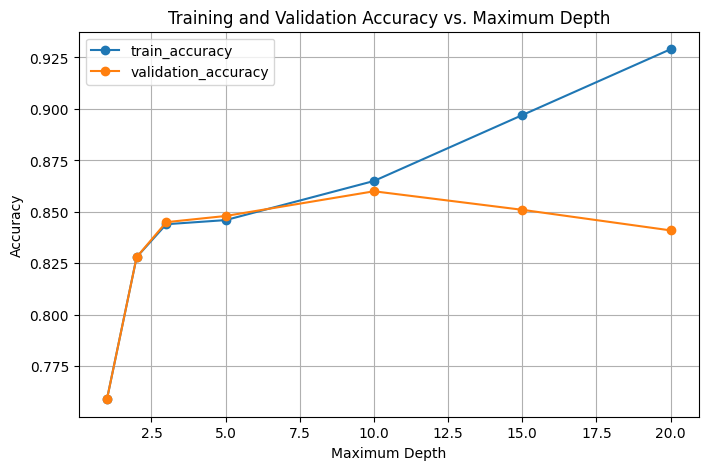

In [46]:
# plot of training and validation set accuracies
plot_metric_curve(
    results_df=depth_results,
    x_col="max_depth",
    y_cols=["train_accuracy", "validation_accuracy"],
    xlabel="Maximum Depth",
    ylabel="Accuracy",
    title="Training and Validation Accuracy vs. Maximum Depth"
)

### bounding the minimum number of nodes in a leaf

In [47]:
# values for minimum number of nodes in a leaf
leaf_values = [1, 2, 5, 10, 20, 50, 100]

leaf_results = run_parameter_sweep(
    model_class=DecisionTreeClassifier,
    param_name="min_samples_leaf",
    param_values=leaf_values,
    X_train=X_train_sub,
    y_train=y_train_sub,
    X_val=X_val,
    y_val=y_val,
    fixed_params={
        "criterion": "entropy",
        "random_state": 42
    }
)

# number of nodes for the different values
leaf_results

,min_samples_leaf,train_accuracy,validation_accuracy,num_nodes
0,1,1.000,0.823,7357
1,2,0.964,0.826,6387
2,5,0.920,0.833,3753
3,10,0.893,0.851,2231
4,20,0.878,0.856,1271
5,50,0.865,0.857,581
6,100,0.859,0.855,321


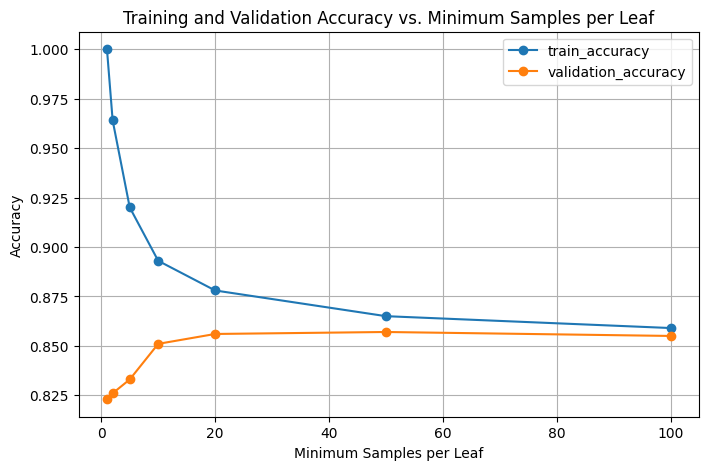

In [48]:
# plot of training and validation set accuracies
plot_metric_curve(
    results_df=leaf_results,
    x_col="min_samples_leaf",
    y_cols=["train_accuracy", "validation_accuracy"],
    xlabel="Minimum Samples per Leaf",
    ylabel="Accuracy",
    title="Training and Validation Accuracy vs. Minimum Samples per Leaf"
)

### cost-complexity pruning

In [52]:
# values for parameter alpha
alpha_values = [0.0, 0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05]

alpha_results = run_parameter_sweep(
    model_class=DecisionTreeClassifier,
    param_name="ccp_alpha",
    param_values=alpha_values,
    X_train=X_train_sub,
    y_train=y_train_sub,
    X_val=X_val,
    y_val=y_val,
    fixed_params={
        "criterion": "entropy",
        "random_state": 42
    }
)

# number of nodes for the different values
alpha_results

,ccp_alpha,train_accuracy,validation_accuracy,num_nodes
0,0.0000,1.0000,0.8225,7357
1,0.0001,0.9634,0.8351,4695
2,0.0005,0.8594,0.8592,115
3,0.0010,0.8543,0.8552,55
4,0.0050,0.8434,0.8451,21
5,0.0100,0.8434,0.8451,13
6,0.0500,0.7593,0.7588,3


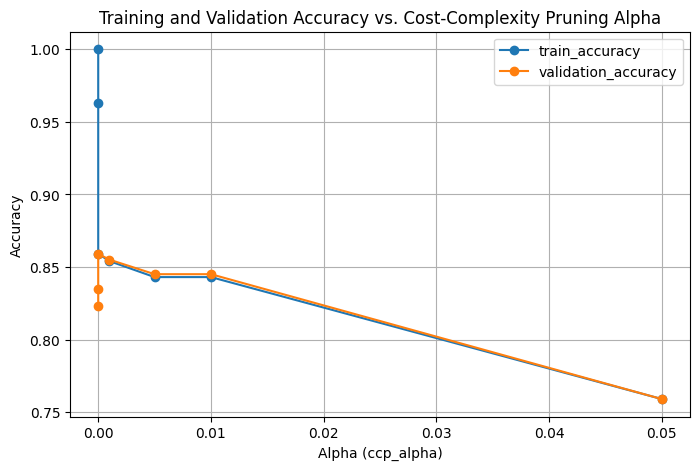

In [50]:
# plot of training and validation set accuracies
plot_metric_curve(
    results_df=alpha_results,
    x_col="ccp_alpha",
    y_cols=["train_accuracy", "validation_accuracy"],
    xlabel="Alpha (ccp_alpha)",
    ylabel="Accuracy",
    title="Training and Validation Accuracy vs. Cost-Complexity Pruning Alpha"
)

# Problem 2 [Random Forest Ensemble]

a. use an existing package to train a random forest ensemble with 10, 50, 100, and 500 decision trees on the ADULT dataset. report accuracy, precision, recall, F1 score, and AUC on both the training and testing sets for T values 10, 50, 100, 500. how do the metrics change as T increases?

In [55]:
# values for number of trees (T)
tree_values = [10, 50, 100, 500]

# run random forest
rf_results = run_ensemble_experiment(
    model_class=RandomForestClassifier,
    n_values=tree_values,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    param_name="n_estimators",
    fixed_params={
        "random_state": 42
    },
    pos_label=">50K"
)

rf_results

,Metric,Training_10,Testing_10,Training_50,Testing_50,Training_100,Testing_100,Training_500,Testing_500
0,Error,0.012,0.155,0.000,0.149,0.0,0.146,0.0,0.146
1,Accuracy,0.988,0.845,1.000,0.851,1.0,0.854,1.0,0.854
2,Precision,0.994,0.715,1.000,0.722,1.0,0.727,1.0,0.726
3,Recall,0.955,0.568,0.999,0.603,1.0,0.609,1.0,0.611
4,F1 Score,0.974,0.633,0.999,0.657,1.0,0.663,1.0,0.664
5,AUC,0.999,0.877,1.000,0.899,1.0,0.903,1.0,0.905


b. compare the metrics obtained for random forest with the decision tree metrics obtained in problem 1. write down some observations.

c. compute the variable importance for each feature and include a plot. discuss your observations on which features contribute most to the prediction.

In [56]:
# get feature importances from the random forest with 100 trees
rf_100 = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_100.fit(X_train, y_train)

importance_df = get_feature_importance_table(
    model=rf_100,
    feature_names=X_train.columns,
    top_n=None
)

importance_df

,Feature,Importance
0,fnlwgt,0.168615
1,age,0.152929
2,education_num,0.108483
3,capital_gain,0.097654
4,hours_per_week,0.083298
...,...,...
87,native_country_Outlying-US(Guam-USVI-etc),0.000030
88,occupation_Armed-Forces,0.000014
89,native_country_Honduras,0.000008
90,workclass_Never-worked,0.000002


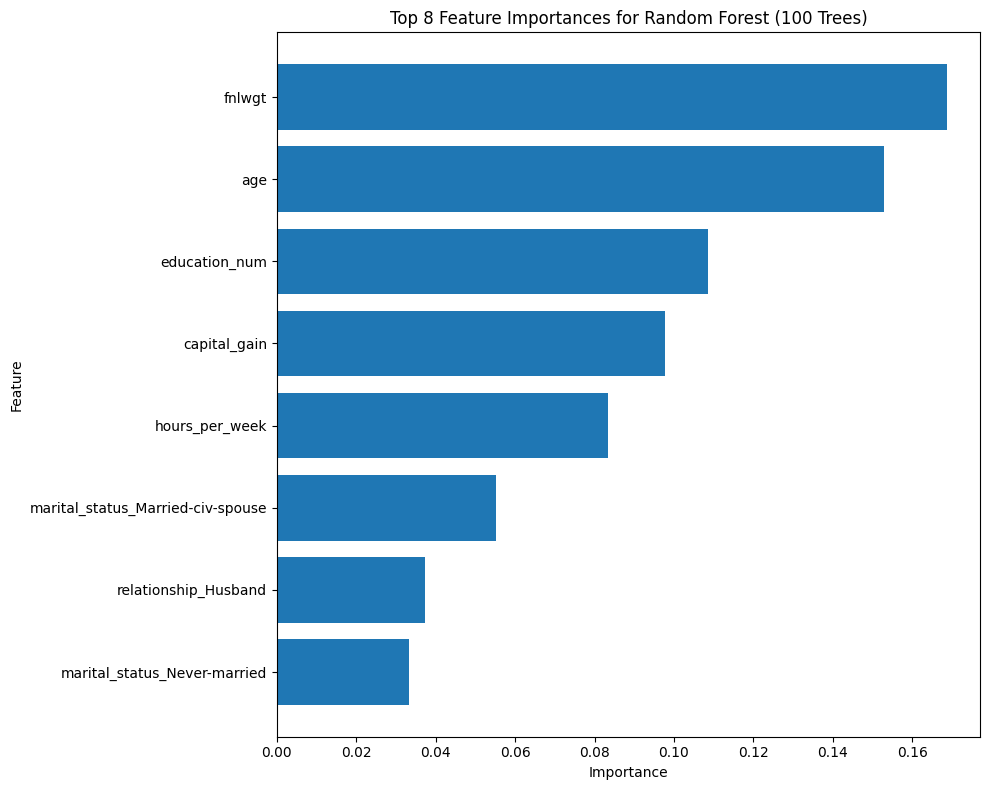

In [59]:
# plot top 8 most important features
top_importance_df = get_feature_importance_table(
    model=rf_100,
    feature_names=X_train.columns,
    top_n=8
)

plot_feature_importance(
    importance_df=top_importance_df,
    title="Top 8 Feature Importances for Random Forest (100 Trees)"
)

# Problem 3 [AdaBoost and GradientBoost Ensemble]

a. use an existing package to train and adaboost and gradientboost ensemble with 10, 50, 100, and 500 base classifiers on the ADULT dataset. use a decision tree classifier as the base classification model. report accuracy, precision, recall, F1 score, and AUC on both the training and testing sets. set max depth of each tree to 3 and learning rate to 0.1

b. compare adaboost, gradientboost, and randomforest ensemble for 10, 50, 100, and 500 base learners by looking at various metrics on the training and testing sets.

c. plot the ROC curves for the decision tree model, random forest with 100 trees, gradientboost and adaboost with 100 trees. discuss your observations.

# Problem 4 [Naive Bayes Classifier]